# M3 — The Residual Emulator and the Hybrid

**retrieve-or-bust · branch `rt-elastic-prototype` · 2026-08-04**

Milestone M3 adds the *learned* half. `forward()` is now
`Rrs = Rrs_ZTT + ΔRrs`: the M2 analytic backbone plus a small Flax MLP trained on
what it misses, differentiable end to end.

The headline, on the full 9960-sample L23 batch: the backbone's **5.93%** rRMS on
held-out scenes becomes **0.30%**, and held-out equals train to two decimals. The
number that keeps that honest is the **linear** baseline — same features, same loss,
no hidden layer — which reaches **2.54%** on the same split. So the MLP's
nonlinearity earns roughly
an 8× improvement, not the 20× that quoting only ZTT would imply.

The result M3 could *not* deliver is just as important, and §6 is about it:
extrapolating to an unseen solar zenith is not reproducible across random seeds.

| Module | What landed |
|---|---|
| `robust/rt/emulator.py` | the MLP, its features, Optax training, `save`/`load`, the trained domain |
| `robust/rt/hybrid.py` | `forward()` / `rrs_forward()`, the `mode` flag, `DomainWarning` |
| `design/py/train_emulator.py` | the real fit (~1 min), which produced the 6.5 KB shipped weights |

Earlier notebooks cover the ground this one builds on and does not repeat:
[notebook 1](rt_elastic_coding_1.ipynb) (JAX, autodiff, float64),
[notebook 2](rt_elastic_coding_2.ipynb) (`rrs` vs `Rrs`, the water/particle split,
`B_p`, the held-out splits), and
[notebook 3](rt_elastic_coding_3.ipynb) (the ZTT backbone, Gordon, the gradient gate).

In [1]:
import sys
from pathlib import Path

REPO = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "robust" / "__init__.py").exists()
)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import time
import warnings

import jax
import jax.numpy as jnp
import numpy as np

from robust.rt import baselines as B
from robust.rt import conventions as C
from robust.rt import emulator as E
from robust.rt import hybrid as H
from robust.rt import validation as V
from robust.rt import ztt as Z
from robust.rt.data import l23 as L
from robust.rt.types import Geometry, IOPs, PhaseParams

print(f"jax {jax.__version__} on {jax.default_backend()}")

jax 0.11.0 on cpu


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# House style, unchanged from notebooks 1-3 so the four read as one set.
INK, INK_MUTED, GRID = "#1a1a1a", "#5c5c5c", "#dcdcdc"
# The categorical set, CVD-validated together: worst adjacent pair dE 21.9 (protan).
# #56B4E9 sits below 3:1 contrast on white, so every series is DIRECTLY LABELLED
# rather than relying on a legend swatch alone.
C_A, C_B, C_C = "#0072B2", "#D55E00", "#56B4E9"   # blue, vermillion, sky
REPLICATE = "#9a9a9a"   # not a category: one de-emphasised grey for seed replicates
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10.5,
    "axes.edgecolor": INK_MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "legend.frameon": False, "figure.facecolor": "white", "axes.facecolor": "white",
})
print("style set")

style set


## 1. The hybrid model, end to end

Before any results, the model itself — every stage, in the order the data flows.
`forward()` is one JAX function; nothing below is a preprocessing step the caller has
to remember.

**Stage 1 — the analytic backbone.** `rrs_ZTT(a, bb_w, bb_p, B_p, θ_s, θ_v, Δφ, λ)`,
the Zaneveld–Twardowski–Tonizzo model transcribed in M2 ([notebook
3](rt_elastic_coding_3.ipynb)). It carries all the radiative transfer: the explicit
backward volume scattering function, the shape factors, the µ∞ and µd cosines, and the
BRDF. This is not a fitted object — its coefficients come from the papers, and it is
what makes the hybrid's extrapolation *bounded* rather than arbitrary.

**Stage 2 — the feature map.** The backbone's inputs reduce to seven dimensionless
numbers (§2 shows why these are complete rather than chosen):

$$x = \bigl[\log_{10} u,\; \eta_{bb},\; B_p,\; \lambda,\; \cos\theta_s,\;
\cos\theta_v,\; \cos\Delta\phi\bigr], \qquad
u = \frac{b_b}{a + b_b}, \quad \eta_{bb} = \frac{b_{bw}}{b_b}$$

evaluated **at each wavelength separately** — one row per (sample, λ) pair, mirroring
the backbone's own locality, which is what lets the emulator work on any wavelength
grid rather than only L23's 81 bands.

**Stage 3 — standardisation.** $\hat{x} = (x - \mu)/\sigma$, with $\mu,\sigma$ measured
on the **training split only** and stored inside the trained `Emulator`. Without this
the raw λ in nanometres (350–750) would swamp a `B_p` of 0.012 in the first layer.

**Stage 4 — the network.** A `tanh` MLP, 7 → 16 → 16 → 1. `tanh` rather than `relu`
because M3's acceptance gate is a finite-difference gradient check and a relu kink
breaks central differences straddling it. The output layer is **zero-initialised**, so
before training $\delta \equiv 0$ and the hybrid *is* the backbone.

**Stage 5 — bound the correction.** $\delta = \delta_{\max}\tanh(r)$ with
$\delta_{\max} = 0.5$, so the learned term can never exceed ±50% however far out of
distribution the inputs go — the hybrid cannot be driven negative or wild by its
learned half. During training a soft penalty in the same percent units as the loss
keeps $|\delta|$ small *inside* the distribution:

$$\mathcal{L} = \underbrace{\mathrm{rRMS}\bigl(rrs_{L23},\, rrs\bigr)}_{\text{the
shared metric, used directly}} + \;0.02 \cdot 100\sqrt{\overline{\delta^2} + \epsilon}$$

**Stage 6 — assemble, then cross the surface.**

$$\Delta rrs = \delta \cdot rrs_{ZTT}, \qquad
rrs = rrs_{ZTT} + \Delta rrs = rrs_{ZTT}\,(1 + \delta), \qquad
R_{rs} = \frac{A\, rrs}{1 - B\, rrs}$$

with $A = 0.52$, $B = 1.7$ (Lee 2002). The correction is defined *below* the surface,
so `mode="hybrid"` equals `mode="ztt"` plus `mode="emulator"` **exactly in `rrs`
space** — and not in `Rrs` space, because that last step is non-linear. All scoring
therefore happens in `rrs` (design §6).

**What is trained, and what merely travels with it.** 417 parameters, and three
non-trained arrays that are just as load-bearing: the standardisation, and the
`domain` — the training range of each feature — which is what lets the model warn a
caller who asks it to extrapolate (§6).

In [3]:
# The packaged weights: the model this section describes, as shipped. Loading them
# needs no training run and no $OS_COLOR, and it exercises the same public path a
# user of the package would take.
packaged = E.load_default()
print(f"loaded {E.DEFAULT_WEIGHTS.name} "
      f"({E.DEFAULT_WEIGHTS.stat().st_size / 1024:.1f} KB)")
print(f"architecture: {len(E.FEATURES)} -> "
      + " -> ".join(str(h) for h in packaged.config.hidden) + " -> 1"
      + f",  tanh,  delta_max = {packaged.config.delta_max}")

# Count the parameters rather than asserting a number in prose.
total = 0
print("\n  layer                shape         parameters")
for layer, tensors in sorted(packaged.params["params"].items()):
    for kind in ("kernel", "bias"):
        arr = tensors[kind]
        total += arr.size
        print(f"  {layer:<12} {kind:<8} {str(arr.shape):<13} {arr.size:>6}")
print(f"  {'':<12} {'':<8} {'total':<13} {total:>6}   (trained)")
print(f"\n  not trained, but stored with them: mean{tuple(packaged.mean.shape)}, "
      f"std{tuple(packaged.std.shape)}, domain{tuple(packaged.domain.shape)}")

loaded emulator_l23.npz (6.5 KB)
architecture: 7 -> 16 -> 16 -> 1,  tanh,  delta_max = 0.5

  layer                shape         parameters
  Dense_0      kernel   (7, 16)          112
  Dense_0      bias     (16,)             16
  Dense_1      kernel   (16, 16)         256
  Dense_1      bias     (16,)             16
  Dense_2      kernel   (16, 1)           16
  Dense_2      bias     (1,)               1
                        total            417   (trained)

  not trained, but stored with them: mean(7,), std(7,), domain(2, 7)


In [4]:
batch_full = None
try:
    batch_full = L.load_batch()
except Exception as exc:
    print(f"L23 not mounted ($OS_COLOR) — falling back to the cached fixture: {exc}")
batch = batch_full if batch_full is not None else L.load_batch(
    reader=L.npz_reader(REPO / "robust/tests/files/l23_small.npz"))

splits = L.make_splits(batch)
wave = np.asarray(batch.wave)
zen = batch.zenith
truth = C.Rrs_to_rrs(batch.Rrs)
ztt = Z.rrs_ZTT(batch.iops, batch.phase_params, batch.geometry, batch.wave)
gordon = B.rrs_gordon(batch.iops)
print(f"{batch.n_sample} samples x {batch.n_wave} lambda"
      f"   ({'full L23' if batch_full is not None else 'committed fixture'})")

# The three modes on identical inputs, from the packaged weights.
args = (batch.iops, batch.phase_params, batch.geometry, batch.wave)
m_ztt = H.rrs_forward(*args, "ztt")
m_emu = H.rrs_forward(*args, "emulator", emulator=packaged, check_domain=False)
m_hyb = H.rrs_forward(*args, "hybrid", emulator=packaged, check_domain=False)
print(f"\nadditivity in rrs space: max |hybrid - (ztt + emulator)| = "
      f"{float(jnp.max(jnp.abs(m_hyb - (m_ztt + m_emu)))):.2e} sr^-1")
above = [H.forward(*args, m, emulator=packaged, check_domain=False)
         for m in ("ztt", "emulator", "hybrid")]
print(f"the same identity in Rrs space:  max discrepancy   "
      f"{float(jnp.max(jnp.abs(above[2] - (above[0] + above[1])))):.2e} sr^-1"
      "   <- the interface is non-linear")

9960 samples x 81 lambda   (full L23)



additivity in rrs space: max |hybrid - (ztt + emulator)| = 0.00e+00 sr^-1
the same identity in Rrs space:  max discrepancy   6.62e-04 sr^-1   <- the interface is non-linear


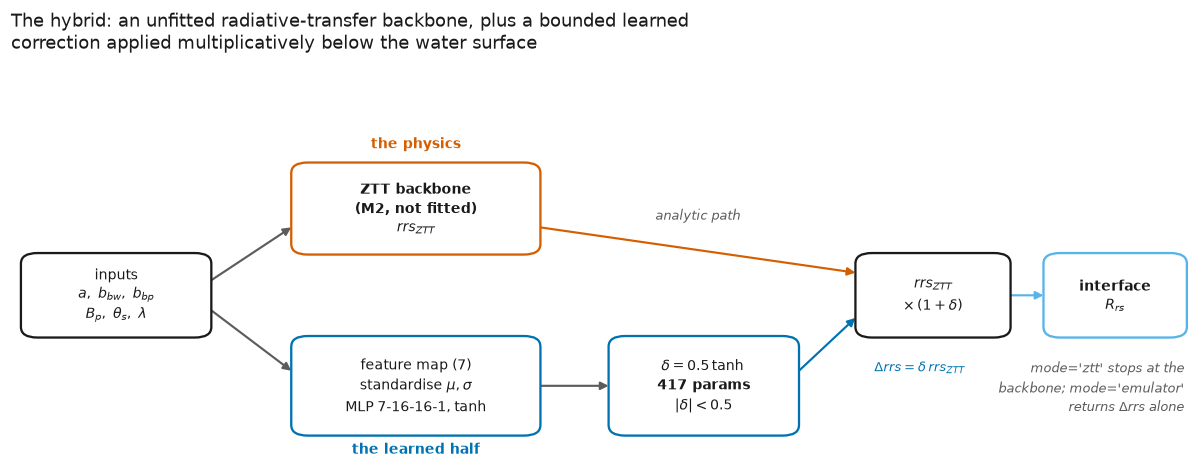

In [5]:
fig, ax = plt.subplots(figsize=(11.0, 4.3))
ax.set_axis_off()
ax.set_xlim(0, 100)
ax.set_ylim(0, 42)

def box(x, y, w, h, text, edge, face="white", fs=9.2, weight="normal"):
    # one rounded stage box with centred text
    ax.add_patch(mpl.patches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.6,rounding_size=1.4",
        linewidth=1.5, edgecolor=edge, facecolor=face, zorder=2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs,
            color=INK, zorder=3, fontweight=weight, linespacing=1.45)

def arrow(x0, y0, x1, y1, colour=INK_MUTED, text=None, dy=1.4):
    # a stage-to-stage arrow, optionally labelled above its midpoint
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), zorder=1,
                arrowprops=dict(arrowstyle="-|>", color=colour, linewidth=1.4,
                                shrinkA=0, shrinkB=0))
    if text:
        ax.text((x0 + x1) / 2, max(y0, y1) + dy, text, ha="center", va="bottom",
                fontsize=8.6, color=INK_MUTED, style="italic")

box(1, 16, 15, 10, "inputs\n$a,\\ b_{bw},\\ b_{bp}$\n$B_p,\\ \\theta_s,\\ \\lambda$",
    INK, fs=9.0)
box(24, 27, 20, 11, "ZTT backbone\n(M2, not fitted)\n$rrs_{ZTT}$", C_B, weight="bold")
box(24, 3, 20, 12,
    "feature map (7)\nstandardise $\\mu,\\sigma$\nMLP 7-16-16-1, tanh", C_A)
box(51, 3, 15, 12, "$\\delta = 0.5\\,\\tanh$\n417 params\n$|\\delta| < 0.5$", C_A,
    weight="bold")
box(72, 16, 12, 10, "$rrs_{ZTT}$\n$\\times\\,(1+\\delta)$", INK, weight="bold")
box(88, 16, 11, 10, "interface\n$R_{rs}$", C_C, weight="bold")

arrow(16.6, 23, 23.4, 30)        # inputs -> backbone
arrow(16.6, 19, 23.4, 11)        # inputs -> features
arrow(44.6, 9, 50.4, 9)
arrow(66.6, 11, 71.4, 18, C_A)
ax.text(73.0, 11.4, "$\\Delta rrs = \\delta\\, rrs_{ZTT}$", ha="left", va="center",
        fontsize=8.8, color=C_A, style="italic")
arrow(44.6, 30, 71.4, 24, C_B, "analytic path", dy=0.6)
arrow(84.6, 21, 87.4, 21, C_C)

ax.text(34, 0.0, "the learned half", ha="center", fontsize=9, color=C_A,
        fontweight="bold")
ax.text(34, 40.5, "the physics", ha="center", fontsize=9, color=C_B,
        fontweight="bold")
ax.text(99.4, 12.6, "mode='ztt' stops at the\nbackbone; mode='emulator'\nreturns "
        "$\\Delta rrs$ alone", ha="right", va="top", fontsize=8.4, color=INK_MUTED,
        style="italic", linespacing=1.5)

fig.suptitle("The hybrid: an unfitted radiative-transfer backbone, plus a bounded "
             "learned\ncorrection applied multiplicatively below the water surface",
             fontsize=12, x=0.01, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

Two properties of that assembly are worth stating plainly, because they are what
distinguish this from fitting a network to `Rrs` directly.

**The physics is never overwritten, only nudged.** The learned term enters as a factor
$(1 + \delta)$ with $|\delta| < 0.5$ enforced by construction, so the backbone sets the
spectral shape, the magnitude and the geometry response, and the emulator can only
adjust them. Far outside the training distribution the correction saturates instead of
diverging — which is a *bound*, not a guarantee of accuracy: §6 shows it going wrong at
an unseen solar zenith while staying comfortably inside that bound.

**Every stage is differentiable, including the learned one.** `jax.grad` of `forward`
w.r.t. `a`, `bb_p`, `B_p` or the geometry runs through the backbone *and* the network,
which is the property the eventual inversion depends on and the reason `tanh` was
preferred to `relu`. §7 gates it against finite differences.

Now the same model on a single water body — the term-by-term decomposition of one
spectrum, using the packaged weights above.

scene index 8453 (60 deg), backbone error 7.0% -- the median of 3320 samples at this zenith


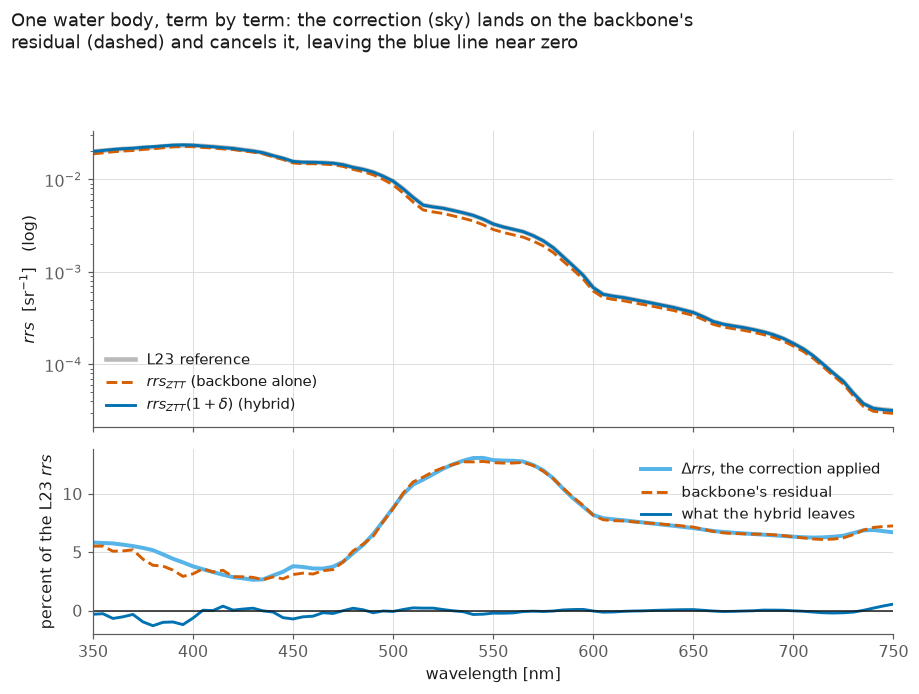

In [6]:
# A representative 60-degree scene rather than a flattering one: the sample whose
# backbone error is closest to the median over all 60-degree samples.
sel = np.where(zen == 60)[0]
err = np.abs(np.asarray((truth - m_ztt) / truth))[sel].mean(axis=1)
i = sel[np.argsort(err)[len(err) // 2]]
print(f"scene index {i} (60 deg), backbone error {err[np.argsort(err)[len(err)//2]]*100:.1f}% "
      f"-- the median of {len(sel)} samples at this zenith")

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(8.4, 6.4), sharex=True, gridspec_kw={"height_ratios": [1.6, 1]})

ax_top.plot(wave, np.asarray(truth[i]), color=INK, lw=3.0, alpha=0.30)
ax_top.plot(wave, np.asarray(m_ztt[i]), color=C_B, lw=1.9, ls="--")
ax_top.plot(wave, np.asarray(m_hyb[i]), color=C_A, lw=1.9)
ax_top.set_yscale("log")
ax_top.set_ylabel("$rrs$  [sr$^{-1}$]   (log)")
ax_top.plot([], [], color=INK, lw=3.0, alpha=0.30, label="L23 reference")
ax_top.plot([], [], color=C_B, lw=1.9, ls="--", label="$rrs_{ZTT}$ (backbone alone)")
ax_top.plot([], [], color=C_A, lw=1.9, label="$rrs_{ZTT}(1+\\delta)$ (hybrid)")
ax_top.legend(loc="lower left", fontsize=9.5)

# All three curves are divided by the L23 reference -- the project's rRMS
# convention (design section 6). Plotting the raw delta here instead would put the
# sky curve ~2 points high, since delta divides by rrs_ZTT, and invite the reading
# that the correction overshoots when in fact only the denominator differs.
correction = np.asarray((m_hyb[i] - m_ztt[i]) / truth[i]) * 100
ax_bot.plot(wave, correction, color=C_C, lw=2.6)
ax_bot.plot(wave, np.asarray((truth[i] - m_ztt[i]) / truth[i]) * 100, color=C_B,
            lw=1.9, ls="--")
ax_bot.plot(wave, np.asarray((truth[i] - m_hyb[i]) / truth[i]) * 100, color=C_A, lw=1.9)
ax_bot.axhline(0.0, color=INK, lw=1.0)
ax_bot.set_ylabel("percent of the L23 $rrs$")
ax_bot.set_xlabel("wavelength [nm]")
ax_bot.plot([], [], color=C_C, lw=2.6, label="$\\Delta rrs$, the correction applied")
ax_bot.plot([], [], color=C_B, lw=1.9, ls="--", label="backbone's residual")
ax_bot.plot([], [], color=C_A, lw=1.9, label="what the hybrid leaves")
ax_bot.legend(loc="upper right", fontsize=9.5, ncols=1)
ax_bot.set_xlim(wave.min(), wave.max())

fig.suptitle("One water body, term by term: the correction (sky) lands on the "
             "backbone's\nresidual (dashed) and cancels it, leaving the blue line "
             "near zero", fontsize=12, x=0.01, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()

The lower panel is the whole model in one picture. The dashed vermillion curve is what
the backbone gets wrong on this scene — the 550 nm hump and the positive offset that
§3 shows are systematic at 60°, reaching 13% here. The sky curve is the correction the
hybrid actually applies, $\Delta rrs$, as a fraction of the same reference: a smooth
function of λ that lands on the dashed curve. Their difference is the blue line, a few
tenths of a percent, near zero across the whole spectrum.

(Both are drawn against the L23 reference, the project's rRMS denominator. The network's
own output $\delta$ is the same curve divided by $rrs_{ZTT}$ instead, which here makes
it ~2 points larger — the correction is applied to the backbone, but scored against the
truth.)

Note what the top panel does *not* show: any visible difference between the three
curves. At the scale `rrs` actually varies over — a decade and a half within this one
spectrum — the backbone is already close, and the argument for the hybrid is entirely
about the last few percent. That is why every figure that follows is a *relative*
one.

## 2. Why the correction is *relative*

The design writes the hybrid as `Rrs = Rrs_ZTT + ΔRrs`, and it stays additive. But
the network does not predict `ΔRrs` in sr⁻¹ — it predicts a dimensionless `δ(λ)`, and
the correction is `Δrrs = δ · rrs_ZTT`.

The reason is dynamic range, and it is worth one measurement rather than an assertion.

In [7]:
truth_np = np.asarray(truth)
rel = np.asarray((truth - ztt) / truth)
mean_spec = truth_np.mean(axis=0)
print(f"\nrrs, mean spectrum:  {mean_spec.min():.2e} .. {mean_spec.max():.2e} sr^-1"
      f"   (factor {mean_spec.max()/mean_spec.min():.0f})")
print(f"rrs, every sample:   {truth_np.min():.2e} .. {truth_np.max():.2e} sr^-1"
      f"   (factor {truth_np.max()/truth_np.min():.0f})")
print(f"the RELATIVE residual: {rel.mean()*100:+.2f}% mean, "
      f"{rel.std()*100:.2f}% sd, |max| {np.abs(rel).max()*100:.1f}%")
print(f"\nso one set of weights would have to emit values "
      f"{truth_np.max()/truth_np.min():.0f}x apart in absolute units,"
      "\nbut only O(1) in relative ones -- and rrms(), the loss, already divides by "
      "the truth.")

# The design's other claim -- that the residual is smooth enough for a small network
# -- as a number, so section 3 does not have to cite it from elsewhere.
lam = (wave - wave.mean()) / np.ptp(wave)
sub = rel[::37]                                    # ~270 spectra, enough for a variance
print("\nfraction of the relative residual's variance explained by a polynomial in "
      "lambda:")
for deg in (1, 5):
    coef = np.polyfit(lam, sub.T, deg)
    fit = np.polyval(coef, lam[:, None]).T
    print(f"   degree {deg}: {100 * (1 - (sub - fit).var() / sub.var()):.1f}%")


rrs, mean spectrum:  3.36e-05 .. 1.41e-02 sr^-1   (factor 419)
rrs, every sample:   1.03e-05 .. 4.42e-02 sr^-1   (factor 4300)
the RELATIVE residual: +2.20% mean, 5.52% sd, |max| 27.8%

so one set of weights would have to emit values 4300x apart in absolute units,
but only O(1) in relative ones -- and rrms(), the loss, already divides by the truth.

fraction of the relative residual's variance explained by a polynomial in lambda:
   degree 1: 83.9%
   degree 5: 96.0%


That factor is the whole argument. An absolute-`ΔRrs` network would have to cover
three and a half decades with one set of weights, and because `rrms` divides by the
truth, a fixed absolute error costs ~4300× more in the darkest band than in the
brightest — the BING lesson, arriving through the back door. Predicting a *relative*
correction makes the target O(1) and makes `δ` directly the quantity the design asks to
keep small.

The smoothness figures above are the design's other central claim, and they set the bar
for what follows: a straight line in λ already accounts for **84%** of the residual's
variance, so that is what a network has to beat before its parameters are justified.

Two guarantees come free with that choice. `δ = delta_max · tanh(·)` is **bounded**,
so no input can drive the hybrid negative or wild; and the output layer is
**zero-initialised**, so an untrained hybrid *is* the backbone and every improvement
below is an improvement over ZTT rather than an artefact of initialisation.

## 3. The features are the backbone's complete state — verified, not asserted

The design suggested `u`, `B_p`, geometry and λ. Rather than guess, note that
`rrs_ZTT` is **scale-invariant**: multiplying `(a, bb_w, bb_p)` by any constant leaves
it unchanged. If that holds, the backbone sees its inputs only through *ratios*, and
two numbers — `u = bb/(a+bb)` and `η_bb = bb_w/bb` — span them exactly.

In [8]:
jax.config.update("jax_enable_x64", True)

# The dtype must be pinned on the ARRAYS, not just enabled globally: these slices
# were built as float32, and x64 alone would leave them there -- the invariance
# would then read as 2e-7 (float32 epsilon) and prove far less than it should.
rows = slice(0, 6)
f64 = lambda x: jnp.asarray(np.asarray(x)[rows], dtype=jnp.float64)
iops0 = IOPs(a=f64(batch.iops.a), bb_w=f64(batch.iops.bb_w), bb_p=f64(batch.iops.bb_p))
phase0 = PhaseParams(B_p=jnp.asarray(batch.phase_params.B_p, dtype=jnp.float64)[rows])
geom0 = Geometry.nadir(f64(batch.geometry.theta_s))
wave64 = jnp.asarray(np.asarray(batch.wave), dtype=jnp.float64)
base = Z.rrs_ZTT(iops0, phase0, geom0, wave64)

print("scale the IOPs by k; does the backbone move?")
for k in (2.0, 10.0, 0.1):
    scaled = IOPs(a=iops0.a * k, bb_w=iops0.bb_w * k, bb_p=iops0.bb_p * k)
    out = Z.rrs_ZTT(scaled, phase0, geom0, wave64)
    print(f"   k = {k:5g}   max relative change {float(jnp.max(jnp.abs(out/base - 1))):.2e}")

# ... and (u, eta_bb) recovers the IOP ratios exactly, so nothing is lost.
u, eta = iops0.u, iops0.bb_w / iops0.bb
bb_rec, bb_w_rec = 1.0, eta                      # fix the arbitrary overall scale
a_rec = bb_rec * (1.0 - u) / u
print(f"\n(u, eta_bb) -> (a : bb_w : bb_p) round-trip, max error "
      f"{float(jnp.max(jnp.abs(a_rec / (iops0.a / iops0.bb) - 1))):.2e}")
jax.config.update("jax_enable_x64", False)

scale the IOPs by k; does the backbone move?
   k =     2   max relative change 0.00e+00
   k =    10   max relative change 6.66e-16
   k =   0.1   max relative change 6.66e-16

(u, eta_bb) -> (a : bb_w : bb_p) round-trip, max error 2.22e-16


Invariant to ~1e-15, which is float64 noise, not physics. That settles the feature
list rather than motivating it: `(log10 u, η_bb, B_p, λ, cos θ_s, cos θ_v, cos Δφ)` is
the backbone's *entire* input state, and no absolute magnitude belongs in it —
radiative transfer in a homogeneous half-space has no absolute length scale either, so
a feature carrying one could only fit noise.

`cos θ_v` and `cos Δφ` are constant in L23 (nadir, zero azimuth), so their weights are
unidentified; they are carried so M5's off-nadir runs need no interface change, and
they standardise to exactly zero. Nothing here is evidence about view geometry.

## 4. Fitting it — the linear baseline first, deliberately

The linear model (`hidden=()`) is the same code path with no hidden layer: same
features, same loss, same optimiser. Reporting it *first* is a guard against reading
the MLP's gain as larger than it is.

In [9]:
t0 = time.perf_counter()
lin, hist_lin = E.fit_l23(batch, splits, config=E.LINEAR_CONFIG, rrs_ztt=ztt)
t_lin = time.perf_counter() - t0
t0 = time.perf_counter()
mlp, hist_mlp = E.fit_l23(batch, splits, rrs_ztt=ztt)
t_mlp = time.perf_counter() - t0

args = (batch.iops, batch.phase_params, batch.geometry, batch.wave)
hyb_lin = ztt * (1.0 + lin.relative_delta(*args))
hyb_mlp = ztt * (1.0 + mlp.relative_delta(*args))
n_par = lambda em: sum(p.size for p in jax.tree_util.tree_leaves(em.params))

test60 = splits.scene_test & (zen == 60)
masks = (("train", splits.scene_train), ("held-out", splits.scene_test),
         ("held-out @60", test60))
print(f"{'rRMS [%]':<30}" + "".join(f"{n:>15}" for n, _ in masks))
print("-" * (30 + 15 * len(masks)))
for label, pred in (("standard Gordon", gordon), ("ZTT backbone", ztt),
                    (f"hybrid, linear ({n_par(lin)} par)", hyb_lin),
                    (f"hybrid, MLP ({n_par(mlp)} par)", hyb_mlp)):
    print(f"{label:<30}" + "".join(
        f"{float(V.rrms(truth[m], pred[m])):>15.2f}" for _, m in masks))
print(f"\nfit time: linear {t_lin:.0f} s, MLP {t_mlp:.0f} s "
      f"({hist_mlp.step[-1]} full-batch Adam steps)")
print(f"correction magnitude |delta| rms: linear {hist_lin.delta_rms[-1]:.2f}%, "
      f"MLP {hist_mlp.delta_rms[-1]:.2f}%   (the residual's own sd is "
      f"{rel.std()*100:.2f}%)")

rRMS [%]                                train       held-out   held-out @60
---------------------------------------------------------------------------


standard Gordon                          7.21           7.21           9.01
ZTT backbone                             5.95           5.93           8.11
hybrid, linear (8 par)                   2.57           2.54           2.48
hybrid, MLP (417 par)                    0.30           0.30           0.32

fit time: linear 9 s, MLP 49 s (3000 full-batch Adam steps)
correction magnitude |delta| rms: linear 5.70%, MLP 6.44%   (the residual's own sd is 5.52%)


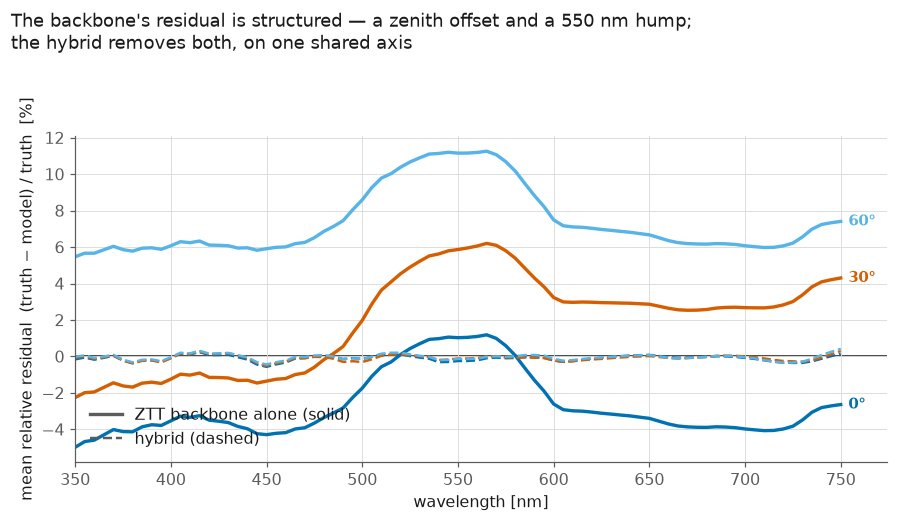

In [10]:
fig, ax = plt.subplots(figsize=(8.2, 4.8))

for k, colour in zip((0.0, 30.0, 60.0), (C_A, C_B, C_C)):
    m = zen == k
    before = np.asarray((truth[m] - ztt[m]) / truth[m]).mean(axis=0) * 100
    after = np.asarray((truth[m] - hyb_mlp[m]) / truth[m]).mean(axis=0) * 100
    ax.plot(wave, before, color=colour, lw=2.2)
    ax.plot(wave, after, color=colour, lw=1.6, ls="--")
    ax.annotate(f"{k:.0f}°", xy=(wave[-1] + 4, before[-1]), color=colour,
                fontweight="bold", fontsize=10, va="center")

ax.axhline(0.0, color=INK, lw=1.0, zorder=1)
ax.set_xlim(wave.min(), wave.max() + 24)
ax.set_xlabel("wavelength [nm]")
ax.set_ylabel("mean relative residual  (truth − model) / truth  [%]")
ax.plot([], [], color=INK_MUTED, lw=2.2, label="ZTT backbone alone (solid)")
ax.plot([], [], color=INK_MUTED, lw=1.6, ls="--", label="hybrid (dashed)")
ax.legend(loc="lower left")
fig.suptitle("The backbone's residual is structured — a zenith offset and a 550 nm "
             "hump;\nthe hybrid removes both, on one shared axis",
             fontsize=12, x=0.01, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

Both structures M2 measured are visible in the solid curves: a **monotone offset in
solar zenith** (the 60° curve sits ~8% high) and a **hump peaking near 550 nm** that
grows with zenith. The dashed curves are the same quantity after the correction, on
the *same* axis — flat on zero at this scale, which is the honest way to show it. The
next figure puts a log axis under them so the remaining error is visible at all.

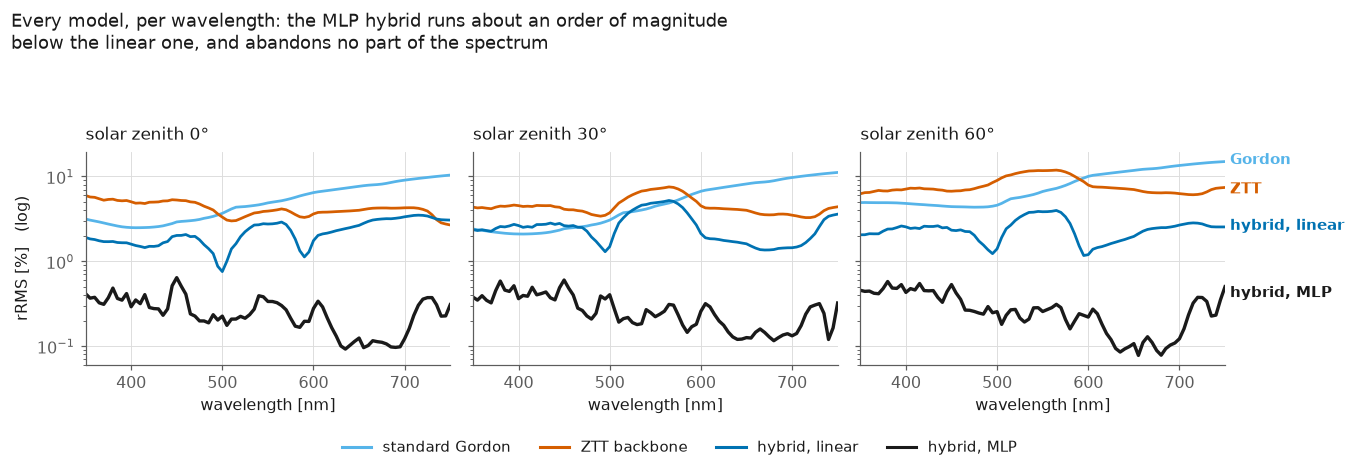

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.2), sharey=True)

for ax, k in zip(axes, (0.0, 30.0, 60.0)):
    m = zen == k
    for pred, colour, lw in ((gordon, C_C, 1.8), (ztt, C_B, 1.8),
                             (hyb_lin, C_A, 1.8), (hyb_mlp, INK, 2.2)):
        ax.plot(wave, np.asarray(V.rrms(truth[m], pred[m], axis=0)), color=colour, lw=lw)
    ax.set_yscale("log")
    ax.set_title(f"solar zenith {k:.0f}°", fontsize=11, loc="left", pad=8)
    ax.set_xlabel("wavelength [nm]")
    ax.set_xlim(wave.min(), wave.max())

axes[0].set_ylabel("rRMS [%]   (log)")
# Direct labels go in the 60-degree panel, where the four curves are furthest
# apart; a legend row carries identity for the other two. (#56B4E9 is below 3:1
# contrast on white, so it must never be identified by colour alone.)
for label, colour, y in (("Gordon", C_C, 15.5), ("ZTT", C_B, 7.0),
                         ("hybrid, linear", C_A, 2.6), ("hybrid, MLP", INK, 0.42)):
    axes[2].annotate(f" {label}", xy=(wave[-1], y), color=colour, fontweight="bold",
                     fontsize=9.5, va="center", annotation_clip=False)
handles = [mpl.lines.Line2D([], [], color=c, lw=2.0) for c in (C_C, C_B, C_A, INK)]
fig.legend(handles, ["standard Gordon", "ZTT backbone", "hybrid, linear",
                     "hybrid, MLP"], loc="lower center", ncols=4, fontsize=9.5,
           bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Every model, per wavelength: the MLP hybrid runs about an order of "
             "magnitude\nbelow the linear one, and abandons no part of the spectrum",
             fontsize=12, x=0.01, ha="left")
fig.tight_layout(rect=(0, 0.07, 1, 0.90))
plt.show()

Two things to read off. First, the improvement is spread across the spectrum: the MLP
hybrid stays between 0.08% and 0.64% at every wavelength, and if anything the *blue*
retains the largest residual — so the good total is not being bought by fixing the
bright end and abandoning the dark one, which is exactly the failure mode relative
weighting exists to prevent. Second, the gap to the linear model is about a decade in
the median but narrows to ~3× at the two wavelengths where the linear model happens to
dip (near 500 and 590 nm), so "an order of magnitude" describes the typical case rather
than a floor.

The linear model sits neatly between, which is what the 84%-of-variance figure in §2
predicts: a straight line captures most of the residual, and the nonlinearity buys the
rest.

## 5. Fit versus generalisation

With 417 parameters against ~645,000 training rows, overfitting would be a surprise.
The learning curve is where that gets checked rather than assumed — and note which
60° curve is plotted: the held-out scenes **at** 60°, not every 60° sample, ~80% of
which are training scenes here and would flatter the model.

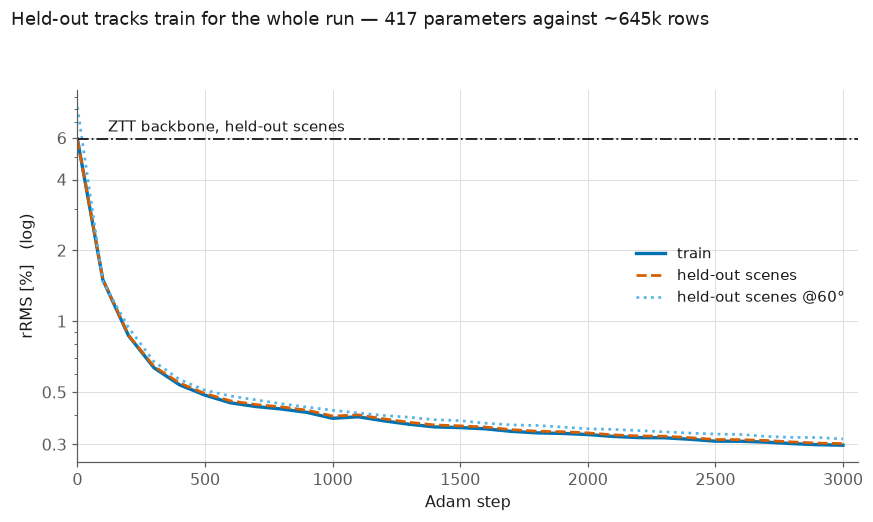

In [12]:
fig, ax = plt.subplots(figsize=(8.0, 4.8))

ax.plot(hist_mlp.step, hist_mlp.fit, color=C_A, lw=2.2)
ax.plot(hist_mlp.step, hist_mlp.eval["scene_test"], color=C_B, lw=1.8, ls="--")
ax.plot(hist_mlp.step, hist_mlp.eval["scene_test_60"], color=C_C, lw=1.8, ls=":")
ax.axhline(float(V.rrms(truth[splits.scene_test], ztt[splits.scene_test])),
           color=INK, lw=1.2, ls="-.")
ax.annotate("ZTT backbone, held-out scenes", xy=(hist_mlp.step[-1] * 0.04, 6.4),
            color=INK, fontsize=9.5)
# A legend, not right-margin annotations: the three curves end within a few
# percent of each other -- which is the point of the figure -- so stacked labels
# there either collide or fall off the axis (the first attempt clipped one).
ax.plot([], [], color=C_A, lw=2.2, label="train")
ax.plot([], [], color=C_B, lw=1.8, ls="--", label="held-out scenes")
ax.plot([], [], color=C_C, lw=1.8, ls=":", label="held-out scenes @60°")
ax.legend(loc="center right", fontsize=9.5)
ax.set_yscale("log")
ax.set_yticks([0.3, 0.5, 1.0, 2.0, 4.0, 6.0])
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v:g}"))
ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
ax.set_xlim(0, hist_mlp.step[-1] * 1.02)
ax.set_xlabel("Adam step")
ax.set_ylabel("rRMS [%]   (log)")
fig.suptitle("Held-out tracks train for the whole run — 417 parameters against "
             "~645k rows", fontsize=12, x=0.01, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

The three curves separate by less than 0.02 percentage points at every step. So on the
split the design cares about — random 20% of scenes, held out *by scene* so no water
body appears in both — the gain is **generalisation, not fit**. MLP(32,32) was also
tried and reached 0.27% against 0.30% (implementation record §5.4), so the design's
"start small" holds: 4× the parameters buys a tenth of the remaining error.

## 6. Where it does not work: extrapolating in solar zenith

Everything above is *interpolation* — the emulator saw 0°, 30° and 60° in training.
The harder question is what happens at an angle it has never seen. Train on 0°/30°
only, score the unseen 60°, and repeat over random seeds with everything else fixed.

In [13]:
SEEDS = (23, 1, 7, 101, 2024)
tr, te = splits.zenith_train, splits.zenith_test
curves, in_sample = [], []
for seed in SEEDS:
    _, hist = E.fit(*args, truth, train=tr, rrs_ztt=ztt,
                    config=E.EmulatorConfig(seed=seed),
                    eval_masks={"unseen60": te})
    curves.append(np.asarray(hist.eval["unseen60"]))
    in_sample.append(float(hist.fit[-1]))
_, hist_lin_z = E.fit(*args, truth, train=tr, rrs_ztt=ztt, config=E.LINEAR_CONFIG,
                      eval_masks={"unseen60": te})

ztt_60 = float(V.rrms(truth[te], ztt[te]))
gor_60 = float(V.rrms(truth[te], gordon[te]))
finals = [c[-1] for c in curves]
print(f"unseen 60 deg, MLP over seeds {SEEDS}:")
print("   " + "  ".join(f"{v:.2f}%" for v in finals)
      + f"   -> median {np.median(finals):.2f}%")
print(f"   linear model: {hist_lin_z.eval['unseen60'][-1]:.2f}%   "
      f"ZTT: {ztt_60:.2f}%   Gordon: {gor_60:.2f}%")
print(f"\nthe SAME fits in sample (0/30 deg): "
      + "  ".join(f"{v:.2f}%" for v in in_sample)
      + f"   linear {hist_lin_z.fit[-1]:.2f}%")

unseen 60 deg, MLP over seeds (23, 1, 7, 101, 2024):
   4.74%  8.37%  7.75%  5.40%  12.24%   -> median 7.75%
   linear model: 6.16%   ZTT: 8.09%   Gordon: 9.01%

the SAME fits in sample (0/30 deg): 0.24%  0.24%  0.26%  0.22%  0.24%   linear 2.40%


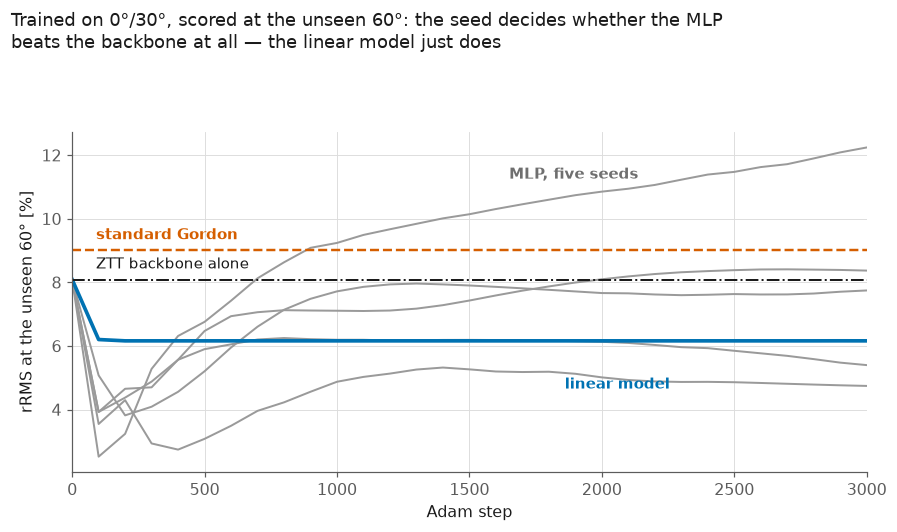

In [14]:
fig, ax = plt.subplots(figsize=(8.2, 4.9))

for i, curve in enumerate(curves):
    ax.plot(hist_mlp.step[:len(curve)], curve, color=REPLICATE, lw=1.3,
            label="MLP, one seed each" if i == 0 else None)
ax.plot(hist_mlp.step[:len(hist_lin_z.eval["unseen60"])],
        hist_lin_z.eval["unseen60"], color=C_A, lw=2.4)
ax.axhline(ztt_60, color=INK, lw=1.3, ls="-.")
ax.axhline(gor_60, color=C_B, lw=1.6, ls="--")

x_end = hist_mlp.step[-1]
ax.annotate("ZTT backbone alone", xy=(x_end * 0.03, ztt_60 + 0.35), color=INK, fontsize=9.5)
ax.annotate("standard Gordon", xy=(x_end * 0.03, gor_60 + 0.35), color=C_B,
            fontweight="bold", fontsize=9.5)
ax.annotate("linear model", xy=(x_end * 0.62, hist_lin_z.eval["unseen60"][-1] - 1.5),
            color=C_A, fontweight="bold", fontsize=9.5)
ax.annotate("MLP, five seeds", xy=(x_end * 0.55, max(finals) * 0.92),
            color="#6f6f6f", fontweight="bold", fontsize=9.5)
ax.set_xlabel("Adam step")
ax.set_ylabel("rRMS at the unseen 60° [%]")
ax.set_xlim(0, x_end)
fig.suptitle("Trained on 0°/30°, scored at the unseen 60°: the seed decides whether "
             "the MLP\nbeats the backbone at all — the linear model just does",
             fontsize=12, x=0.01, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

This is M3's uncomfortable result, and the reason the milestone's claim is scoped to
the scene split. Five identical configurations differing only in initialisation land
anywhere from *better than* the backbone to *much worse than Gordon*, and most of them
drift upward as training proceeds — while all five finish within 0.04 pp of each other
in sample, at ~0.24%. Nothing visible from inside the training set distinguishes the
seed that extrapolates at 4.7% from the one at 12.2%.
The grey is deliberately one colour: these are replicates, not five things to tell
apart.

The cause is not mysterious. `cos θ_s` spans [0.866, 1.0] in that training set and 60°
needs 0.5, so every `tanh` unit is evaluated outside its fitted range, where nothing
constrains it. The **linear** model cannot bend, and that inability is exactly what
saves it: it gives up a lot in sample (2.40% against 0.24%) and returns a stable 6.16%
at the unseen angle, beating both references.

JXP's call (Q6) was **report and defer**: 60° extrapolation is a stretch goal, trusted
outputs at that angle can be used if we obtain them, and the emulator must not be used
at larger angles without warning the user. That last part is now enforced in code
rather than in prose — the trained input range travels *with* the weights.

In [15]:
# A sun at 75 degrees: outside anything L23 contains.
low_sun = Geometry.nadir(jnp.full_like(batch.geometry.theta_s, 75.0))
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    H.rrs_forward(batch.iops, batch.phase_params, low_sun, batch.wave, "hybrid")
print(f"75° sun -> {len(caught)} warning ({caught[0].category.__name__}):\n")
print("   " + str(caught[0].message))

# In range means the rows it was trained on. Note that the held-out scenes graze
# the boundary by ~4e-4 of a span, which is why the check has a tolerance
# (E.DOMAIN_TOL) rather than testing the raw min/max -- see the markdown below.
tr = splits.scene_train
trained_rows = (
    IOPs(a=batch.iops.a[tr], bb_w=batch.iops.bb_w[tr], bb_p=batch.iops.bb_p[tr]),
    PhaseParams(B_p=batch.phase_params.B_p[tr]),
    Geometry.nadir(batch.geometry.theta_s[tr]),
    batch.wave,
)
with warnings.catch_warnings(record=True) as quiet:
    warnings.simplefilter("always")
    H.rrs_forward(*trained_rows, "hybrid", emulator=mlp)
print(f"\nthe rows it was trained on -> {len(quiet)} warnings")
print(f"\nheld-out scenes, how far past the boundary they reach:")
for name, b in mlp.out_of_domain(*args, tol=0.0).items():
    print(f"   {name}: {b.excess:.1e} of the trained span "
          f"({b.fraction:.1e} of values) -> below the {E.DOMAIN_TOL:.0%} tolerance")

75° sun -> 1 warning (DomainWarning):

   the emulator is being evaluated outside its training range, where M3 measured its accuracy to be unreliable and occasionally worse than the analytic backbone: cos_theta_s 100.0% of values outside [0.5, 1], worst 0.2588 — 48% of the trained span beyond it. Consider mode='ztt'. (cos_theta_s decreases with solar zenith, so a low sun breaches the lower bound.)



the rows it was trained on -> 0 warnings

held-out scenes, how far past the boundary they reach:
   eta_bb: 3.7e-04 of the trained span (3.7e-06 of values) -> below the 1% tolerance


`DomainWarning` has its own category, so a pipeline that must never silently
extrapolate can promote it to an error, and a study that means to can silence it once.
It is a boundary check on concrete values, so it is skipped under `jit` and `grad` —
stated in the docstring rather than left to be discovered.

The tolerance above is not slackness, and this notebook is why it exists. The first
version of the check compared against the raw training min/max, and it warned on the
*full batch* — because held-out scenes legitimately graze the boundary, by the ~4e-4
of a span printed above, for a handful of values in 800,000. A check that fires on that
gets silenced, and then the case that matters — a 75° sun sitting **48%** of a span
past the `cos_theta_s` floor, three orders of magnitude further out — passes unnoticed.
`emulator.DOMAIN_TOL` sits between them with ~27× of headroom below and ~48× above.

## 7. The gradient gate, and what the correction costs

The gradient is the property the future inversion depends on, so it is gated on the
*full* `forward`, emulator included — not on the backbone alone as in
[notebook 3](rt_elastic_coding_3.ipynb) §5. Same protocol: float64, dtype pinned on
the arrays, and a per-variable step, since `theta_s` is O(30) while the IOP-like
variables are O(1e-3).

In [16]:
jax.config.update("jax_enable_x64", True)
rows = np.where(zen == 30.0)[0][:3]
f64 = lambda x: jnp.asarray(np.asarray(x)[rows], dtype=jnp.float64)
a0, bbw0, bbp0 = f64(batch.iops.a), f64(batch.iops.bb_w), f64(batch.iops.bb_p)
Bp0, th0 = f64(batch.phase_params.B_p), f64(batch.geometry.theta_s)
w64 = jnp.asarray(wave, dtype=jnp.float64)

def scalar(shift, name):
    '''Mean hybrid Rrs with one variable shifted.'''
    o = dict.fromkeys(("a", "bb_p", "B_p", "theta_s"), 0.0)
    o[name] = shift
    return jnp.mean(H.forward(
        IOPs(a=a0 + o["a"], bb_w=bbw0, bb_p=bbp0 + o["bb_p"]),
        PhaseParams(B_p=Bp0 + o["B_p"]), Geometry.nadir(th0 + o["theta_s"]),
        w64, "hybrid", emulator=mlp, check_domain=False))

print("d/dx of the hybrid forward: autodiff vs central differences")
for name, h in (("a", 1e-6), ("bb_p", 1e-9), ("B_p", 1e-8), ("theta_s", 1e-3)):
    ana = float(jax.grad(lambda s: scalar(s, name))(jnp.asarray(0.0, dtype=jnp.float64)))
    hh = jnp.asarray(h, dtype=jnp.float64)
    num = float((scalar(hh, name) - scalar(-hh, name)) / (2 * hh))
    print(f"   {name:8s} step {h:.0e}   autodiff {ana:+.6e}   "
          f"relative difference {abs(ana/num - 1):.1e}")
jax.config.update("jax_enable_x64", False)

d/dx of the hybrid forward: autodiff vs central differences


   a        step 1e-06   autodiff -1.511215e-01   relative difference 2.5e-09
   bb_p     step 1e-09   autodiff +9.522084e-01   relative difference 1.0e-09
   B_p      step 1e-08   autodiff +3.821041e-04   relative difference 1.6e-07


   theta_s  step 1e-03   autodiff -5.724717e-08   relative difference 2.1e-07


In [17]:
def throughput(mode, **kw):
    '''Jitted wall time per call, averaged over five runs after a warm-up.'''
    f = jax.jit(lambda i, p, g, w: H.rrs_forward(i, p, g, w, mode, **kw))
    f(*args).block_until_ready()
    t0 = time.perf_counter()
    for _ in range(5):
        f(*args).block_until_ready()
    return (time.perf_counter() - t0) / 5

t_ztt = throughput("ztt")
t_hyb = throughput("hybrid", emulator=mlp, check_domain=False)
n = batch.n_sample * batch.n_wave
print(f"jitted, {batch.n_sample} x {batch.n_wave}:")
print(f"   mode='ztt'      {t_ztt*1e3:6.2f} ms   {n/t_ztt/1e6:6.0f} M sample-lambda/s")
print(f"   mode='hybrid'   {t_hyb*1e3:6.2f} ms   {n/t_hyb/1e6:6.0f} M sample-lambda/s"
      f"   = {t_hyb/t_ztt:.1f}x the backbone")

jitted, 9960 x 81:
   mode='ztt'        3.78 ms      213 M sample-lambda/s
   mode='hybrid'    16.45 ms       49 M sample-lambda/s   = 4.4x the backbone


All four variables agree to ~2e-7 or better, inside the 1e-6 gate, so `jax.grad`
through the emulator is trustworthy. (The gate in `test_hybrid.py` reaches ~1e-9 for
`a` and `bb_p`; the looser figures here are the central difference's own truncation
error against a fully trained network's larger curvature, not a defect in the
gradient.)

The hybrid costs **~5×** the backbone — 16 ms against 3.2 ms for the 9960 × 81 batch in
the cell above. CPU wall-clock wanders ~20% between runs on this machine, so the ratio
is the reproducible part, not the milliseconds.
That is more than the naive expectation, because the emulator evaluates a 417-parameter
network at every one of 806,760 sample-wavelength points, and it is still ~50 M
sample·λ/s, so the advantage over calling an RT solver survives with room to spare.

## 8. What M3 leaves open

- **Geometry extrapolation** (§6) is the main risk carried into M4. Three ways
  forward: early stopping on a geometry-held-out curve (but L23 has only three
  angles), a seed ensemble, or an architecture whose geometry dependence cannot bend.
  Choosing between them needs more than one unseen angle.
- **`mode="emulator"` is the correction term, not a model.** Because the emulator is
  parameterised as a relative correction, "learned-only" would need a differently
  trained network predicting `rrs` across four decades. That belongs beside PR05 and
  O25 in M4's protocol.
- **`B_p` still covers only a 1.75× slice** of the design's 7.5× band
  ([notebook 2](rt_elastic_coding_2.ipynb)), so none of this is evidence about
  phase-function generalisation. M5's HydroLight runs are what would test it.
- **Equation (8)'s `m1..m16`** are still missing from the ZTT paper, so µ∞ comes from
  Twardowski & Tonizzo (2017); the emulator has been absorbing whatever error that
  choice introduces, which is worth revisiting when the coefficients arrive.